In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
import glob
import os

In [ ]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
sims=xr.open_dataset("../output/timeseries_from1D.nc")
temp=xr.open_dataset("../output/timeseries_from2D.nc")

best=sims.sel(sim=305)
T_srf_best=temp.sel(sim=305)

# Observations
A_obs=1.7
V_obs=7.4

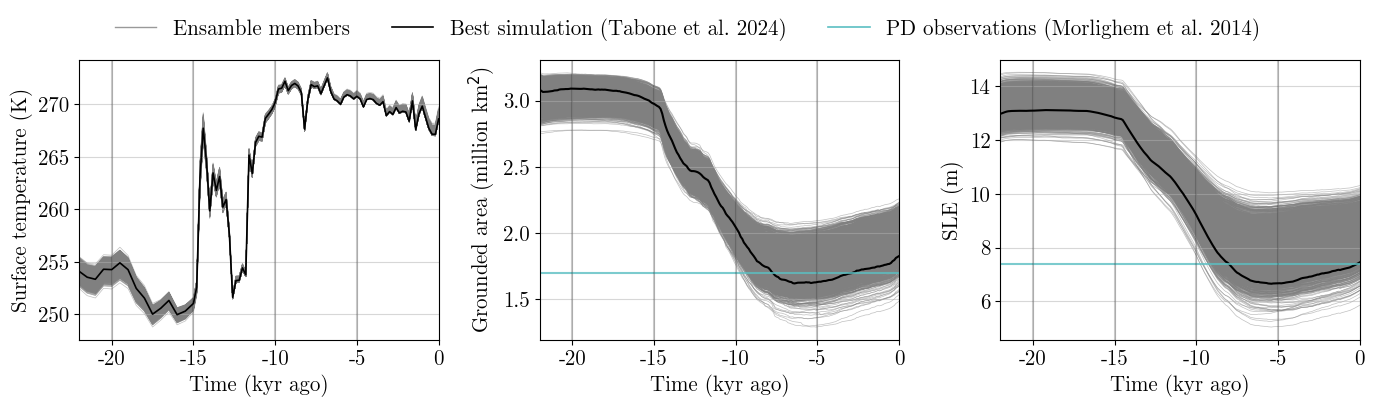

In [8]:

fig, axs = plt.subplots(1,3,figsize=(14,4))

for index in sims.sim:
    sim=sims.sel(sim=index)
    axs[1].plot(sim.time/1e3, sim.A_ice_g, color='gray',alpha=0.5, linewidth=0.5,zorder=1)
    axs[2].plot(sim.time/1e3, sim.V_sle, color='gray',alpha=0.5, linewidth=0.5,zorder=1)

for index in temp.sim:
    T_srf= temp.sel(sim=index)
    axs[0].plot(T_srf.time/1e3, T_srf.T_ann, color='gray',alpha=0.5, linewidth=0.5,zorder=1)
    # axs[0].plot(T_srf.time/1e3, T_srf.T_sum, color='orange',alpha=0.5, linewidth=0.5,zorder=1)

axs[0].plot(T_srf_best.time/1e3, T_srf_best.T_ann, color='black', linewidth=1.2,zorder=2)
axs[1].plot(best.time/1e3, best.A_ice_g, color='black', linewidth=1.5,zorder=2)
axs[2].plot(best.time/1e3, best.V_sle, color='black', linewidth=1.5,zorder=2)

axs[1].axhline(y=A_obs, color='#5BBFC2', linestyle='-', alpha=0.8,linewidth=1.5,zorder=2)
axs[2].axhline(y=V_obs, color='#5BBFC2' , linestyle='-', alpha=0.8,linewidth=1.5,zorder=2)

axs[0].set_ylabel('Surface temperature (K)')
axs[1].set_ylabel('Grounded area (million km$^2$)')
axs[2].set_ylabel('SLE (m)')

for ax in axs:
    ax.set_xlabel('Time (kyr ago)')
    ax.grid(alpha=0.5,zorder=5)
    ax.axvline(x=-20, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-15, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-10, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-5, color='black', linestyle='-', alpha=0.2)
    ax.set_xlim(-22,0)
    
# Legend 
gray_line  = mlines.Line2D([], [], color='gray',  alpha=0.8, linewidth=1,  label='Ensamble members')
black_line = mlines.Line2D([], [], color='black', linewidth=1.2,             label='Best simulation (Tabone et al. 2024)')
blue_line  = mlines.Line2D([], [], color='#5BBFC2', linewidth=1.2,          label='PD observations (Morlighem et al. 2014)')

leg = fig.legend(handles=[gray_line, black_line, blue_line],
           loc='upper center',
           ncol=3,
           bbox_to_anchor=(0.5, 1.05))
leg.get_frame().set_linewidth(0)

plt.tight_layout()
plt.subplots_adjust(top=0.9)


In [10]:
fig.savefig("../figs/timeseries.png", dpi=300)
